In [1]:
import seaborn as sns
tip_df = sns.load_dataset('tips')
tip_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

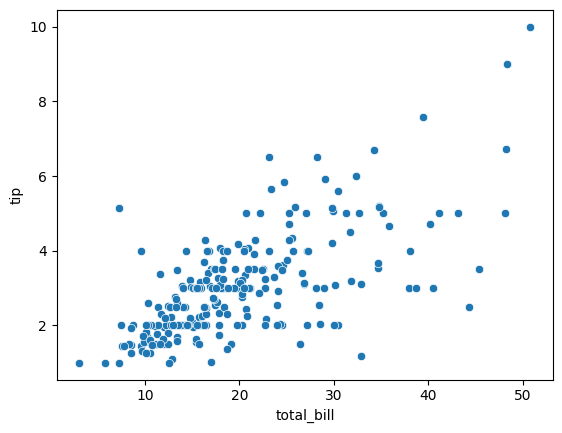

In [2]:
sns.scatterplot(x = 'total_bill', y = 'tip',
                data = tip_df)


<Axes: xlabel='total_bill', ylabel='tip'>

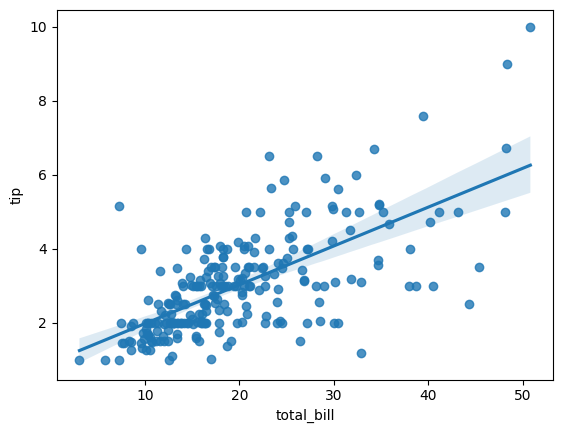

In [3]:

sns.regplot(x = 'total_bill', y = 'tip',
                data = tip_df)

In [4]:
#y=mx+c
y=1.5*6+1.1
y

10.1

In [5]:
#y=b0*x0+b1*x1+b2*x2....+bn*xn+c+error

In [6]:
import pandas as pd
energy_df = pd.read_csv(r"Resources/appliance_energy.csv")
energy_df.head()

,Temperature (°C),Energy Consumption (kWh)
0,22.490802,2.292604
1,34.014286,3.251925
2,29.639879,3.009868
3,26.973170,1.703533
4,18.120373,1.702201


In [7]:
energy_df.rename(columns = {"Temperature (°C)": ' temperature',
                            "Energy Consumption (kWh)": 'energy_consumption'},
                 inplace = True)

In [8]:
energy_df.head(1)

,temperature,energy_consumption
0,22.490802,2.292604


In [9]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    temperature        100 non-null    float64
 1   energy_consumption  100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [10]:
energy_df.isna().sum()

 temperature          0
energy_consumption    0
dtype: int64

<Axes: xlabel=' temperature', ylabel='energy_consumption'>

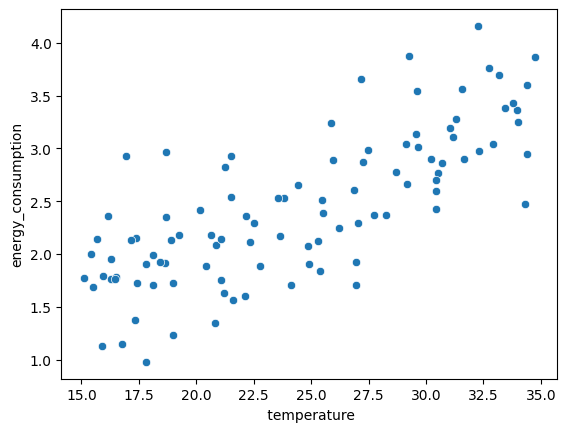

In [11]:
sns.scatterplot(x = ' temperature', y = 'energy_consumption',data = energy_df)

In [12]:
# Identifying input and output features
X = energy_df[[' temperature']]
y = energy_df['energy_consumption']

In [13]:
X[:5]

,temperature
0,22.490802
1,34.014286
2,29.639879
3,26.973170
4,18.120373


In [14]:
y[:5]

0    2.292604
1    3.251925
2    3.009868
3    1.703533
4    1.702201
Name: energy_consumption, dtype: float64

In [15]:
# To split the data into training and testing
from sklearn.model_selection import train_test_split
y = energy_df['energy_consumption'] # Re-defining y to ensure it's the correct Series
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [16]:
X.shape

(100, 1)

In [17]:
X_train.shape

(80, 1)

In [18]:
y.shape

(100,)

In [19]:
y_train.shape

(80,)

In [20]:
X_train[:5]

,temperature
55,33.437485
88,32.744255
26,18.993476
42,15.687770
69,34.737739


In [21]:
# Selecting  the algorithm
from sklearn.linear_model import LinearRegression
my_model = LinearRegression()

# Train the model
my_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = my_model.predict(X_test)
y_pred[:5]

array([1.6858187 , 3.18154068, 2.96097494, 2.76354868, 2.0370856 ])

In [23]:
y_test[:5]


83    1.955394
53    3.037917
70    2.426014
45    2.370351
44    2.413076
Name: energy_consumption, dtype: float64

In [24]:
#Evalute the model

from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error is :{mse :2f}")
print(f"R2  Score is: {r2:2f}")

Mean Squared Error is :0.163425
R2  Score is: 0.611948


In [25]:
my_model.intercept_

np.float64(0.22196391661907633)

In [26]:
my_model.coef_

array([0.08996618])

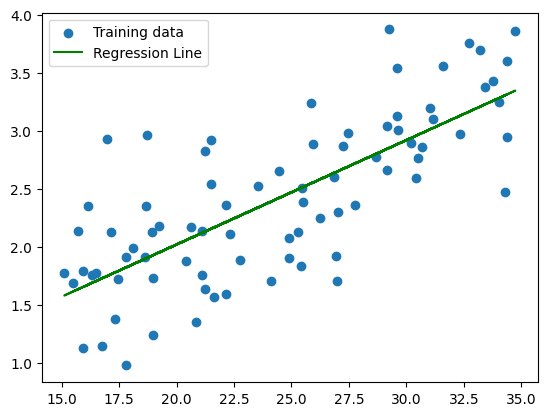

In [27]:
import matplotlib.pyplot as plt
plt.scatter(X_train, y_train, label = "Training data")
y_train_pred = my_model.predict(X_train)
plt.plot(X_train, y_train_pred, label ="Regression Line", color = 'g')
plt.legend()
plt.show()

In [28]:
import joblib as jb
jb.dump(my_model, 'energy_model.pkl')

['energy_model.pkl']

In [29]:
# using the saved model
#load the model
import numpy as np
model = jb.load(r"energy_model.pkl")
#take the input
temp = float(input("Enter the temperature of the device: "))
new_data = np.array([[temp]])
prediction = model.predict(new_data)
print(f"The predicted energy consumption is: {prediction[0]:.2f} kWh")

The predicted energy consumption is: 1.21 kWh


/home/haze/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [30]:
pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samuelcortinhas/house-price-prediction-seattle")

print("Path to dataset files:", path)

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/haze/.cache/kagglehub/datasets/samuelcortinhas/house-price-prediction-seattle/versions/1


In [32]:
import pandas as pd
import numpy as np
train_df = pd.read_csv(path + "/train.csv")
test_df = pd.read_csv(path + "/test.csv")

In [33]:
house_df = pd.concat([train_df, test_df])
house_df.head()

,beds,baths,size,size_units,lot_size,lot_size_units,zip_code,price
0,3,2.5,2590.0,sqft,6000.00,sqft,98144,795000.0
1,4,2.0,2240.0,sqft,0.31,acre,98106,915000.0
2,4,3.0,2040.0,sqft,3783.00,sqft,98107,950000.0
3,4,3.0,3800.0,sqft,5175.00,sqft,98199,1950000.0
4,2,2.0,1042.0,sqft,NaN,NaN,98102,950000.0


In [34]:
house_df.drop(["size_units", "lot_size_units", "lot_size", "zip_code"], axis=1, inplace=True)

In [35]:
house_df.head()

,beds,baths,size,price
0,3,2.5,2590.0,795000.0
1,4,2.0,2240.0,915000.0
2,4,3.0,2040.0,950000.0
3,4,3.0,3800.0,1950000.0
4,2,2.0,1042.0,950000.0


In [36]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2521 entries, 0 to 504
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   beds    2521 non-null   int64  
 1   baths   2521 non-null   float64
 2   size    2521 non-null   float64
 3   price   2521 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 98.5 KB


In [37]:
house_df['baths'] = house_df['baths'].fillna(house_df['baths'].median())
house_df['beds'] = house_df['beds'].fillna(house_df['beds'].median())

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target for house price prediction
X = house_df[['beds', 'baths', 'size']]
y = house_df['price']

# Check for missing values in features and target
if X.isnull().sum().any():
    X = X.fillna(X.median())
if y.isnull().sum() > 0:
    y = y.fillna(y.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
house_price_mlr_model = LinearRegression()
house_price_mlr_model.fit(X_train, y_train)

# Predict
y_pred = house_price_mlr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Display first 5 predictions
y_pred[:5]

Mean Squared Error: 95286065421.89
R2 Score: 0.66


array([ 810811.7692704 , 1254018.59860267,  754053.60209371,
        720109.39718429,  840186.15532681])

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 224269.03
Root Mean Squared Error: 308684.41
R2 Score: 0.66


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
X_train_scaled[:5]

array([[ 1.70773859,  1.81629538,  0.29630475],
       [ 0.10307721, -0.16511776,  0.12538874],
       [-0.69925349,  2.31164867,  0.09334199],
       [-0.69925349, -1.15582433, -1.09238779],
       [ 0.9054079 ,  0.33023552,  0.14675324]])

In [42]:
from sklearn.linear_model import LinearRegression
house_price_mlr_model_new = LinearRegression()
house_price_mlr_model_new.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
house_price_mlr_model_new.intercept_

np.float64(969496.8715277778)

In [44]:
house_price_mlr_model_new.coef_

array([-142996.60205021,   83649.424737  ,  477684.26062115])

In [45]:
y_pred_scaled = house_price_mlr_model_new.predict(X_test_scaled)
y_pred_scaled[:5]

array([ 810811.7692704 , 1254018.59860264,  754053.6020937 ,
        720109.3971843 ,  840186.1553268 ])

In [46]:
import joblib as jb
jb.dump(house_price_mlr_model_new, 'house_price_model.pkl')

['House_price_predictor.pkl']

['House_price_predictor.pkl']

In [51]:
model = jb.load('house_price_model.pkl')
bed = int(input("Enter the number of bedrooms: "))
bath = int(input("Enter the number of bathrooms: "))
sz = float(input("Enter the size of the house in sq m: "))
new_data = np.array([[bed, bath, sz]])
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print(f"The predicted price of the house is: ${prediction[0]:.2f}")

The predicted price of the house is: $894911.95


/home/haze/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
